**Import Libraries**

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix,
    f1_score
)


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

print("Libraries imported")

Libraries imported


**Load Dataset**

In [16]:
# Load dataset
data = np.load('../data/raw/gesture_dataset.npz')
X = data['features']
y = data['labels']

# Load metadata
with open('../data/raw/gesture_dataset_metadata.json', 'r') as f:
    metadata = json.load(f)

GESTURE_CLASSES = {int(k): v for k, v in metadata['gesture_classes'].items()}

print(f"  Dataset Loaded:")
print(f"  Features: {X.shape}")
print(f"  Labels: {y.shape}")
print(f"  Classes: {list(GESTURE_CLASSES.values())}")

  Dataset Loaded:
  Features: (500, 57)
  Labels: (500,)
  Classes: ['fist', 'open_palm', 'thumbs_up', 'peace', 'pointing', 'ok_sign']


**Data Preprocessing**

In [21]:
# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Data Split:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")

# Feature scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n Feature scaling applied")
print(f"  Mean: {X_train_scaled.mean():.4f}")
print(f"  Std: {X_train_scaled.std():.4f}")


 Data Split:
  Training set: 400 samples
  Test set: 100 samples

 Feature scaling applied
  Mean: -0.0000
  Std: 0.9823


**Train Multiple Models**

In [26]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate each model
results = {}

print(" TRAINING MODELS")


for name, model in models.items():
    print(f"\n Training {name}")
    
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'f1_score': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred
    }
    
    print(f" Accuracy: {accuracy:.4f}")
    print(f" F1-Score: {f1:.4f}")
    print(f" CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


 TRAINING MODELS

 Training Logistic Regression
 Accuracy: 1.0000
 F1-Score: 1.0000
 CV Score: 0.9925 (+/- 0.0061)

 Training SVM (RBF)
 Accuracy: 1.0000
 F1-Score: 1.0000
 CV Score: 0.9875 (+/- 0.0079)

 Training Random Forest
 Accuracy: 1.0000
 F1-Score: 1.0000
 CV Score: 0.9925 (+/- 0.0061)

 Training K-Nearest Neighbors
 Accuracy: 1.0000
 F1-Score: 1.0000
 CV Score: 1.0000 (+/- 0.0000)


**Compare Model Performance**


 Model Comparison:
              Model  Accuracy  F1-Score  CV Mean   CV Std
Logistic Regression       1.0       1.0   0.9925 0.006124
          SVM (RBF)       1.0       1.0   0.9875 0.007906
      Random Forest       1.0       1.0   0.9925 0.006124
K-Nearest Neighbors       1.0       1.0   1.0000 0.000000


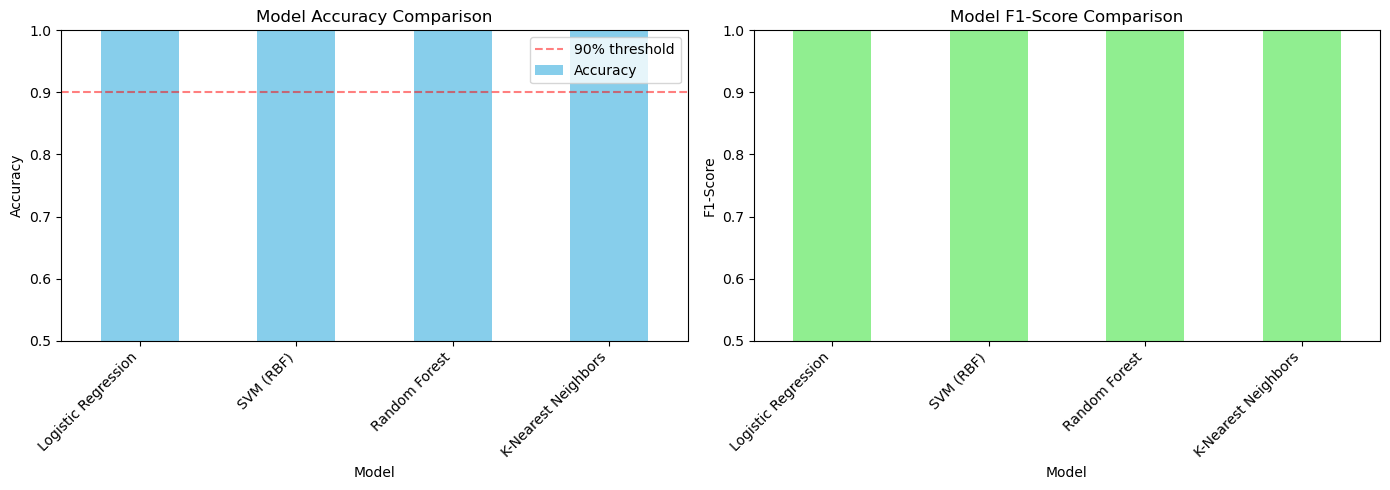

In [35]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'F1-Score': [r['f1_score'] for r in results.values()],
    'CV Mean': [r['cv_mean'] for r in results.values()],
    'CV Std': [r['cv_std'] for r in results.values()]
})

print("\n Model Comparison:")
print(comparison_df.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#  1: Accuracy comparison
ax1 = axes[0]
comparison_df.plot(x='Model', y='Accuracy', kind='bar', ax=ax1, 
                   color='skyblue', legend=False)
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_ylim(0.5, 1.0)
ax1.axhline(y=0.9, color='r', linestyle='--', alpha=0.5, label='90% threshold')
ax1.legend()
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

#  2: F1-Score comparison
ax2 = axes[1]
comparison_df.plot(x='Model', y='F1-Score', kind='bar', ax=ax2, 
                   color='lightgreen', legend=False)
ax2.set_ylabel('F1-Score')
ax2.set_title('Model F1-Score Comparison')
ax2.set_ylim(0.5, 1.0)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [37]:
# Select best model
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = results[best_model_name]['model']

print(f"\n Best Model: {best_model_name}")
print(f"   Accuracy: {results[best_model_name]['accuracy']:.4f}")


 Best Model: Logistic Regression
   Accuracy: 1.0000


**Evaluation of Best Model**

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Getting predictions from best model
y_pred = results[best_model_name]['y_pred']

# Find labels actually present in test set
labels_present = np.unique(y_test)

In [44]:
print(f"\n Classification Report for {best_model_name}:")

report = classification_report(
    y_test,
    y_pred,
    labels=labels_present,
    target_names=[GESTURE_CLASSES[i] for i in labels_present],
    digits=4
)

print(report)


 Classification Report for Logistic Regression:
              precision    recall  f1-score   support

        fist     1.0000    1.0000    1.0000        20
   open_palm     1.0000    1.0000    1.0000        20
   thumbs_up     1.0000    1.0000    1.0000        20
    pointing     1.0000    1.0000    1.0000        20
     ok_sign     1.0000    1.0000    1.0000        20

    accuracy                         1.0000       100
   macro avg     1.0000    1.0000    1.0000       100
weighted avg     1.0000    1.0000    1.0000       100



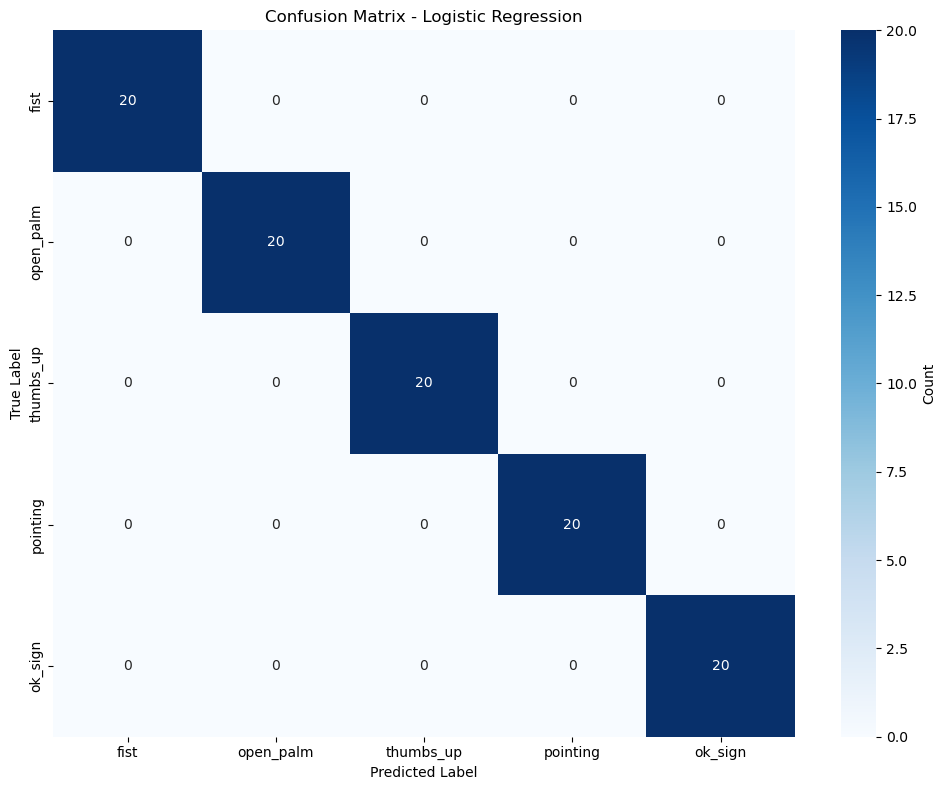

In [46]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels_present
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[GESTURE_CLASSES[i] for i in labels_present],
    yticklabels=[GESTURE_CLASSES[i] for i in labels_present],
    cbar_kws={'label': 'Count'}
)

plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [48]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("\n Per-Class Accuracy:")
for label, acc in zip(labels_present, per_class_accuracy):
    print(f"  {GESTURE_CLASSES[label]}: {acc:.4f}")


 Per-Class Accuracy:
  fist: 1.0000
  open_palm: 1.0000
  thumbs_up: 1.0000
  pointing: 1.0000
  ok_sign: 1.0000


**Save Best Model**

In [51]:
import os
os.makedirs('../models', exist_ok=True)

# Save model
model_path = '../models/gesture_classifier.pkl'
joblib.dump(best_model, model_path)

['../models/gesture_classifier.pkl']

In [53]:
# Save scaler
scaler_path = '../models/scaler.pkl'
joblib.dump(scaler, scaler_path)

['../models/scaler.pkl']

In [55]:

# Save model metadata
model_metadata = {
    'model_name': best_model_name,
    'accuracy': float(results[best_model_name]['accuracy']),
    'f1_score': float(results[best_model_name]['f1_score']),
    'cv_mean': float(results[best_model_name]['cv_mean']),
    'cv_std': float(results[best_model_name]['cv_std']),
    'num_features': X_train.shape[1],
    'gesture_classes': GESTURE_CLASSES,
    'trained_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'training_samples': X_train.shape[0],
    'test_samples': X_test.shape[0]
}

In [57]:
metadata_path = '../models/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(model_metadata, f, indent=4)

print(f"\n Model saved successfully!")
print(f"  Model: {model_path}")
print(f"  Scaler: {scaler_path}")
print(f"  Metadata: {metadata_path}")


 Model saved successfully!
  Model: ../models/gesture_classifier.pkl
  Scaler: ../models/scaler.pkl
  Metadata: ../models/model_metadata.json


**Prediction Test**

In [60]:
def test_prediction(model, scaler, sample_idx=0):
    
    # Get a test sample
    sample = X_test[sample_idx].reshape(1, -1)
    true_label = y_test[sample_idx]
    
    # Scale and predict
    sample_scaled = scaler.transform(sample)
    prediction = model.predict(sample_scaled)[0]
    
    # Get prediction probabilities if available
    if hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(sample_scaled)[0]
        
        print(f"\n Prediction Test:")
        print(f"  True gesture: {GESTURE_CLASSES[true_label]}")
        print(f"  Predicted: {GESTURE_CLASSES[prediction]}")
        print(f"\n  Probabilities:")
        for i, prob in enumerate(probabilities):
            print(f"    {GESTURE_CLASSES[i]}: {prob:.4f}")
    else:
        print(f"\n Prediction Test:")
        print(f"  True gesture: {GESTURE_CLASSES[true_label]}")
        print(f"  Predicted: {GESTURE_CLASSES[prediction]}")

# Test prediction
test_prediction(best_model, scaler, sample_idx=0)


 Prediction Test:
  True gesture: thumbs_up
  Predicted: thumbs_up

  Probabilities:
    fist: 0.0033
    open_palm: 0.0000
    thumbs_up: 0.9939
    peace: 0.0027
    pointing: 0.0001
